## Что такое LLM?

Давайте представим, что вы открыли чат и написали: «Сегодня отличная погода, хочется...». И телефон тут же подсказывает: «...прогуляться». Вы не задумываетесь, как он это сделал. Просто сработало автодополнение - та же технология, что предлагает вам слова в мессенджере или код в редакторе по типу Copilot.

**LLM** - это то же автодополнение, только мощнее, и, самое главное, видящее весь контекст вашего предложения. Например, кто помнит, были такие программы-автодополнения T9, они работали и предлагали следующее слово после введенного вами.

Внутри LLM находится следующая механика, если описать её кратко:

1. Текст разбивается на токены - кусочки слов или символы.
2. Каждый токен превращается в вектор - список чисел, который несёт смысловую нагрузку.
3. Эти векторы проходят через слои нейросети, где перемножаются, складываются и взвешиваются.
4. На выходе модель выдаёт распределение вероятностей: для каждого возможного следующего токена - число от 0 до 1, показывающее, насколько он вероятен.
5. Мы выбираем токен - либо самый вероятный, либо с элементом случайности - и добавляем его к тексту.
6. Повторяем.

Модель не «знает», что такое гравитация или как писать стихи. Она знает, что после последовательности «закон всемирного тяготения» с высокой вероятностью следует «Ньютона», потому что видела эту связку в обучающих данных тысячи раз. Вся «осмысленность» возникает не из понимания, а из способности улавливать статистические закономерности в огромных объёмах текста.

Откуда слово **"большая"**?

Оно означает три вещи:

- *Большой словарь:* десятки тысяч токенов вместо сотен.
- *Большой контекст:* модель «помнит» не последнее слово, а целые абзацы.
- *Большое количество параметров:* миллионы или миллиарды весов, которые настраиваются в процессе обучения.

- Если вы спросите: «Сколько будет 2+2?», модель ответит «4» не потому, что посчитала, а потому, что в её тренировочных данных после «2+2=» чаще всего стоит «4». Для простых примеров вроде «2+2» модель чаще всего опирается на то, что видела этот ответ в обучающих данных. Настоящего пошагового вычисления внутри нет - мы это увидим, когда будем разбирать архитектуру.
- Если вы попросите написать код, она сгенерирует синтаксически правильный фрагмент, но не гарантирует, что он решит вашу задачу - только то, что он похож на рабочие решения из обучающей выборки.

## Как вообще пришли к LLM

Чтобы понять, куда мы движемся, полезно оглянуться на то, откуда мы пришли. История языковых моделей - это не просто хронология публикаций, это история борьбы за контекст и понимание связей между словами. Я буду называть это эпохами, хотя, наверное, это неправильно, но мне так удобнее уложить это в голове.


**Эпоха 1:** мы вручную прописывали логику: если пользователь написал «Привет», ответь «Здравствуйте». Такие системы работали строго в рамках своего алгоритма. Шаг в сторону - и бот терялся...

**Эпоха 2:** пришла статистика. Мы перестали писать правила и начали считать частоту слов. Модели учились предсказывать следующее слово, анализируя, какие комбинации встречались в текстах чаще. Появились N-граммы: модель смотрела на два-три предыдущих слова и искала четвёртое. Это был прогресс, но контекст оставался коротким. Модель не помнила, о чём шла речь в начале абзаца. Она видела только ближайшие слова.

**Эпоха 3:** Настоящий прорыв случился с приходом глубокого обучения и рекуррентных сетей (RNN). Мы научились подавать текст последовательно: слово за словом, как поток. Сеть запоминала состояние после каждого токена и передавала его дальше. Это позволяло учитывать контекст длиннее нескольких слов. Но у подхода была фундаментальная проблема: последовательная обработка. Чтобы понять последнее слово в предложении, сеть должна была пройти через все предыдущие. Это было медленно. Нельзя было распараллелить вычисления на мощных видеокартах, потому что каждое следующее действие зависело от предыдущего.

**Революция:** В 2017 году вышла статья «Attention Is All You Need». Исследователи предложили архитектуру Трансформер. Ключевая идея заключалась в механизме внимания (Attention). Вместо того чтобы читать текст последовательно, модель получила возможность «смотреть» на все слова предложения одновременно и вычислять связи между любыми парами слов, независимо от расстояния. Слово «банк» могло сразу обратиться к слову «деньги», даже если между ними десять других слов. Это решило проблему памяти и дало огромный прирост скорости за счет параллелизации.

Именно на этой архитектуре построены все современные LLM. В 2018 году OpenAI выпустила GPT-1, показав, что трансформер можно использовать для генерации текста в архитектуре decoder-only. Затем вышел GPT-2 с открытыми весами и деталями обучения - пусть и не сразу: OpenAI сначала придержала модель из-за опасений злоупотребления, и полную версию открыли только спустя несколько месяцев. Исследователи со всего мира, в том числе и я, используют эти данные и принципы как основу для понимания. С выходом GPT-3 ситуация изменилась: компания перестала публиковать веса и подробности обучающего корпуса, хотя архитектуру в общих чертах описала в статье Language Models are Few-Shot Learners» (2020)

С тех пор индустрия разделилась. С одной стороны - закрытые гиганты вроде GPT-4 или Claude, доступные только через API. С другой - компании, выкладывающие веса в открытый доступ: Meta с LLaMA, DeepSeek и другие. Поверх них уже растёт сообщество доработок и форков. Они меньше по размеру, но их архитектура прозрачна. Мы можем заглянуть внутрь, посмотреть на веса, понять, как именно работает внимание.

Например, если перейти на Hugging Face - это центральный хаб для сообщества машинного обучения, особенно в области NLP и больших языковых моделей. Мы можем посмотреть настройки, веса модели **gpt-oss-120b**

https://huggingface.co/openai/gpt-oss-120b/tree/main

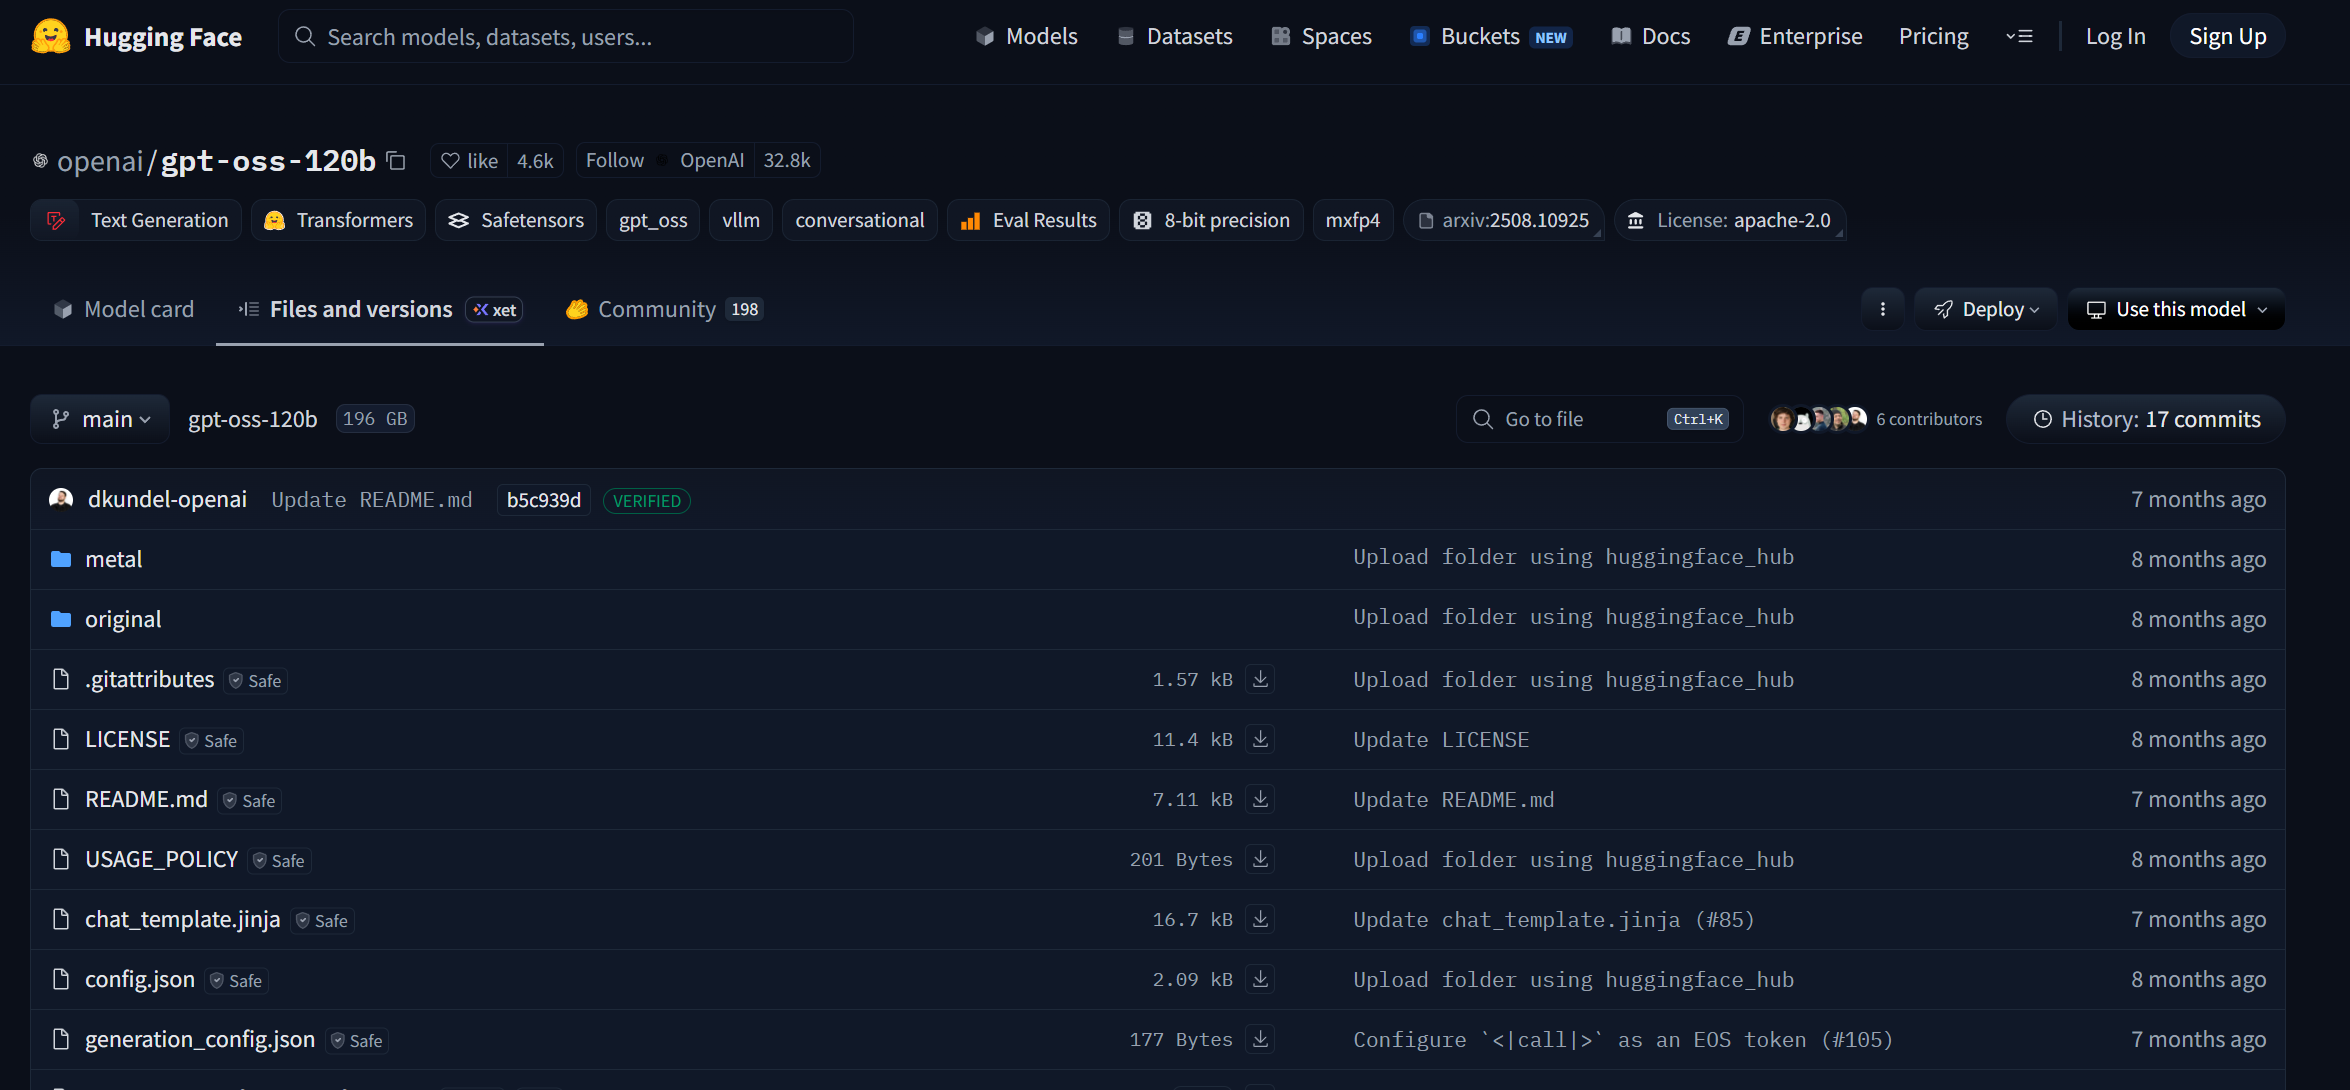

Скорее всего, вы задаете такой вопрос: «А зачем мне делать свою модель, если можно скачать другие?», тем более что сейчас можно быстро на своем компьютере развернуть модели с помощью сервиса Ollama? И на практике, наверно, так и есть, но мы же исследователи и хотим понимать, как все работает. Например, в школе, когда мы изучаем сложение или вычитание, такого вопроса никто не задает, а ведь есть же калькуляторы. Вот и здесь так, лучше понимать технологию, чем не понимать и считать, что это все магия.

### Как работает LLM в общих чертах

**Токены**

Компьютер не понимает слова как мы и не может с ними работать. Он превращает текст в токены.

Примерно так (условно):

- «Привет» → [П, ри, вет] или [Привет] (зависит от токенизатора)

 - «машина» → [ма, ши, на]

 Это необходимо, чтобы модель одинаково работала с редкими словами, именами, числами, языками, кодом.

**Векторные представления**

Каждый токен превращается в вектор (список чисел). Это как координаты точки в многомерном пространстве.

Аналогия:

- Если слово «кот» и «кошка» похожи по смыслу, их точки рядом.

- «Кот» и «экскаватор» - далеко.

**Внимание (attention) - «на что смотреть»**

Когда вы читаете предложение:

*«Маша положила яблоко в коробку, потому что она…»*

Чтобы понять, кто «она», мозг смотрит назад: «она» = Маша.
Трансформер делает похожее: каждое слово смотрит на другие и решает, что важнее.

**Выход: вероятности следующего токена**

В конце модель выдаёт список вероятностей:

- следующий токен «…» с вероятностью 0.23

- следующий токен «…» с вероятностью 0.17

- …

Потом выбираем один токен, дописываем, и повторяем.

Теперь, когда вы понимаете, что это такое и зачем - давайте начнём разбираться, как это работает изнутри.